# 1. Install Packages

In [12]:
pip install fastai nibabel opencv-python imageio tqdm ipywidgets pillow

Note: you may need to restart the kernel to use updated packages.Collecting fastai
  Using cached fastai-2.8.7-py3-none-any.whl.metadata (8.6 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached pillow-12.1.1-cp310-cp310-win_amd64.whl.metadata (9.0 kB)
  Using cached fastdownload-0.0.7-py3-none-any.whl.metadata (5.5 kB)
  Using cached fastcore-1.12.24-py3-none-any.whl.metadata (3.4 kB)
  Using cached fasttransform-0.0.2-py3-none-any.whl.metadata (7.6 kB)
  Using cached torchvision-0.25.0-cp310-cp310-win_amd64.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl.metadata (52 kB)
  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached fastprogress-1.1.5-py3-none-any.whl.metadata (4.9 kB)
  Using 

# 2. Import

In [56]:
import os
import glob
import cv2
import imageio

import numpy as np 
import pandas as pd 
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from tqdm.notebook import tqdm
from ipywidgets import *
from PIL import Image
from matplotlib.pyplot import figure

from fastai.basics import *
from fastai.vision.all import *
from fastai.data.transforms import *

# 3. Data Preparation

In [3]:
# Create a meta file for nii files processing

base_dir = r'C:\Users\Admin\Documents\Uni\DS200\liver_segmentation\datasets' 

file_list = []
for dirname, _, filenames in os.walk(base_dir):
    for filename in filenames:
        if filename.endswith('.nii') or filename.endswith('.nii.gz'):
            dirname = dirname.replace('\\', '/')
            file_list.append((dirname, filename)) 

df_files = pd.DataFrame(file_list, columns=['dirname', 'filename'])

In [4]:
# Map CT scan and label 
df_files["mask_dirname"]  = ""
df_files["mask_filename"] = ""

mask_folder_path = f"{base_dir}/segmentations"

for i in range(131):
    ct = f"volume-{i}.nii"
    mask = f"segmentation-{i}.nii"
    
    df_files.loc[df_files['filename'] == ct, 'mask_filename'] = mask
    df_files.loc[df_files['filename'] == ct, 'mask_dirname'] = mask_folder_path

df_files = df_files[df_files.mask_filename != ''].sort_values(by=['filename']).reset_index(drop=True) 

print(df_files.head())

                                                                     dirname  \
0  C:/Users/Admin/Documents/Uni/DS200/liver_segmentation/datasets/volume_pt1   
1  C:/Users/Admin/Documents/Uni/DS200/liver_segmentation/datasets/volume_pt1   
2  C:/Users/Admin/Documents/Uni/DS200/liver_segmentation/datasets/volume_pt1   
3  C:/Users/Admin/Documents/Uni/DS200/liver_segmentation/datasets/volume_pt6   
4  C:/Users/Admin/Documents/Uni/DS200/liver_segmentation/datasets/volume_pt7   

         filename  \
0    volume-0.nii   
1    volume-1.nii   
2   volume-10.nii   
3  volume-100.nii   
4  volume-101.nii   

                                                                   mask_dirname  \
0  C:\Users\Admin\Documents\Uni\DS200\liver_segmentation\datasets/segmentations   
1  C:\Users\Admin\Documents\Uni\DS200\liver_segmentation\datasets/segmentations   
2  C:\Users\Admin\Documents\Uni\DS200\liver_segmentation\datasets/segmentations   
3  C:\Users\Admin\Documents\Uni\DS200\liver_segmentation\dat

In [5]:
def read_nii(filepath):
    '''
    Reads .nii file and returns pixel array
    '''
    ct_scan = nib.load(filepath)
    array   = ct_scan.get_fdata()
    array   = np.rot90(np.array(array))
    return(array)

In [6]:
# Read sample

sample = 0
sample_ct = read_nii(df_files.loc[sample,'dirname']+"/"+df_files.loc[sample,'filename'])
sample_mask = read_nii(df_files.loc[sample,'mask_dirname']+"/"+df_files.loc[sample,'mask_filename'])

print(f'CT Shape:   {sample_ct.shape}\nMask Shape: {sample_mask.shape}')

CT Shape:   (512, 512, 75)
Mask Shape: (512, 512, 75)


In [7]:
print(np.amin(sample_ct), np.amax(sample_ct))
print(np.amin(sample_mask), np.amax(sample_mask))

-3024.0 1410.0
0.0 2.0


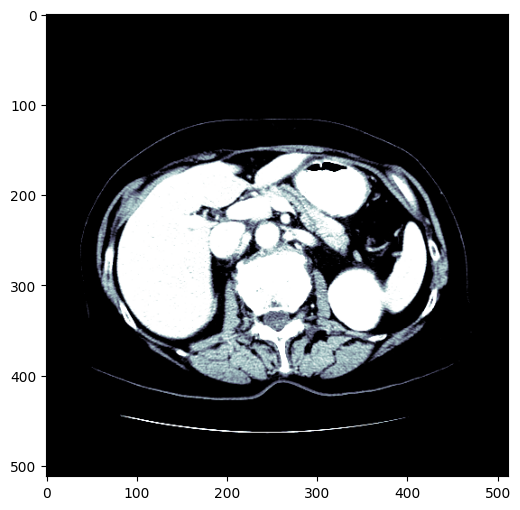

In [8]:
# Preprocess the nii file 
# Source https://docs.fast.ai/medical.imaging

dicom_windows = types.SimpleNamespace(
    brain=(80,40),
    subdural=(254,100),
    stroke=(8,32),
    brain_bone=(2800,600),
    brain_soft=(375,40),
    lungs=(1500,-600),
    mediastinum=(350,50),
    abdomen_soft=(400,50),
    liver=(150,30),
    spine_soft=(250,50),
    spine_bone=(1800,400),
    custom = (200,60)
)

@patch
def windowed(self:Tensor, w, l):
    px = self.clone()
    px_min = l - w//2
    px_max = l + w//2
    px[px<px_min] = px_min
    px[px>px_max] = px_max
    return (px-px_min) / (px_max-px_min)

figure(figsize=(8, 6), dpi=100)

plt.imshow(tensor(sample_ct[..., 55].astype(np.float32)).windowed(*dicom_windows.liver), cmap=plt.cm.bone);

In [54]:
def plot_sample(array_list):
    '''
    Plots a slice with FIXED colors: Liver (Red) and Tumor (Green)
    '''
    fig = plt.figure(figsize=(20,16), dpi=100)
    
    ct_slice = array_list[0]
    mask_slice = array_list[1]

    # 1. Định nghĩa bảng màu tĩnh (0: Nền, 1: Gan, 2: U)
    # Dùng cho ô số 3 (Mask độc lập): Nền màu Đen cho dễ nhìn
    cmap_mask_only = ListedColormap(['black', 'red', 'green'])
    # Dùng cho ô số 4 (Overlay): Nền phải là 'none' (trong suốt) để không che mất ảnh CT
    cmap_overlay = ListedColormap(['none', 'red', 'green']) 

    plt.subplot(1,4,1)
    plt.imshow(ct_slice, cmap='bone')
    plt.title('1. Original Image', fontsize=14)
    plt.axis('off')
    
    plt.subplot(1,4,2)
    # Giữ nguyên cách áp dụng windowing của bạn
    plt.imshow(tensor(ct_slice.astype(np.float32)).windowed(*dicom_windows.liver), cmap='bone')
    plt.title('2. Windowed Image', fontsize=14)
    plt.axis('off')
             
    plt.subplot(1,4,3)
    # Khóa thang đo bằng vmin=0, vmax=2
    plt.imshow(mask_slice, cmap=cmap_mask_only, vmin=0, vmax=2)
    plt.title('3. Mask (Đỏ: Gan, Xanh: U)', fontsize=14)
    plt.axis('off')
    
    plt.subplot(1,4,4)
    # Vẽ ảnh CT nền trước
    plt.imshow(tensor(ct_slice.astype(np.float32)).windowed(*dicom_windows.liver), cmap='bone')
    # Vẽ đè Mask lên trên với độ trong suốt alpha=0.5
    plt.imshow(mask_slice, alpha=0.5, cmap=cmap_overlay, vmin=0, vmax=2)
    plt.title('4. Liver & Mask Overlay', fontsize=14)
    plt.axis('off')
    
    plt.show()

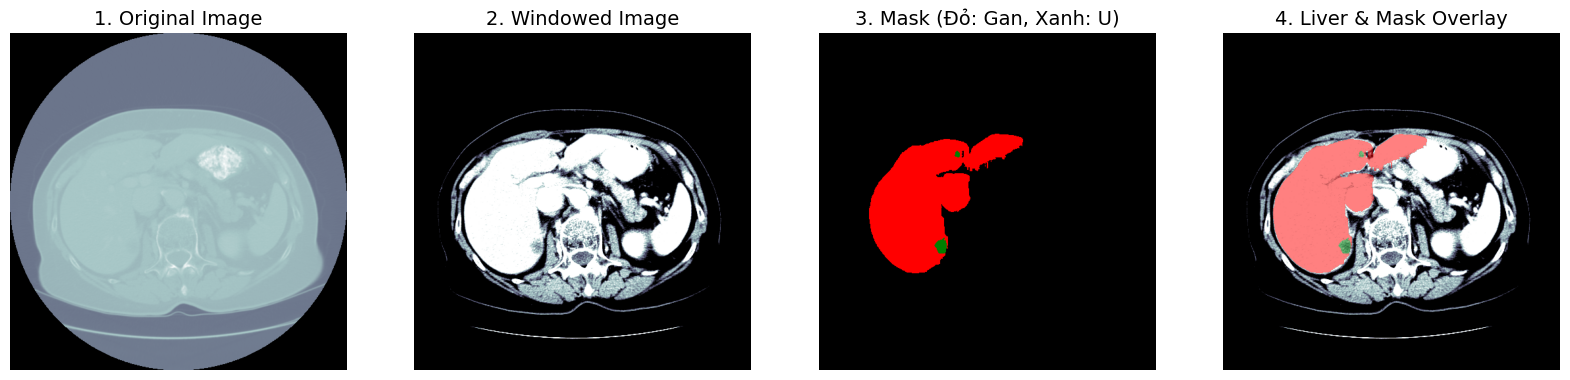

In [58]:
sample = 57

sample_slice = tensor(sample_ct[...,sample].astype(np.float32))

plot_sample([sample_ct[..., sample],
             sample_mask[..., sample]])

In [22]:
# Check the mask values
mask = Image.fromarray(sample_mask[...,sample].astype('uint8'), mode="L")
unique, counts = np.unique(mask, return_counts=True)
print(np.array((unique, counts)).T)

[[     0 244111]
 [     1  18033]]


In [46]:
total_slices = sample_mask.shape[2]

slices_with_tumor = []

for i in range(total_slices):
    slice_2d = sample_mask[..., i]
    
    if np.any(slice_2d == 2):
        slices_with_tumor.append(i)

print(f"Tổng số lát cắt trong khối 3D này: {total_slices}")
print("-" * 30)

if len(slices_with_tumor) > 0:
    print(f"🎉 Đã tìm thấy khối u ở các lát cắt số:\n{slices_with_tumor}")
    print(f"=> Tổng cộng có {len(slices_with_tumor)} lát cắt chứa khối u.")
else:
    print("Trắng tay! Khối 3D này của bệnh nhân hoàn toàn không có khối u nào (chỉ có gan khỏe mạnh hoặc background).")

Tổng số lát cắt trong khối 3D này: 75
------------------------------
🎉 Đã tìm thấy khối u ở các lát cắt số:
[46, 56, 57, 58, 59, 60, 61, 62, 65, 66, 67, 68, 69, 70, 71, 72]
=> Tổng cộng có 16 lát cắt chứa khối u.


<Axes: >

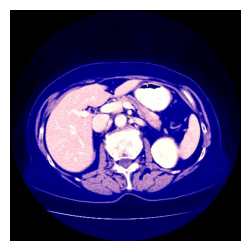

In [23]:
# Preprocessing functions
# Source https://docs.fast.ai/medical.imaging

class TensorCTScan(TensorImageBW): _show_args = {'cmap':'bone'}

@patch
def freqhist_bins(self:Tensor, n_bins=100):
    "A function to split the range of pixel values into groups, such that each group has around the same number of pixels"
    imsd = self.view(-1).sort()[0]
    t = torch.cat([tensor([0.001]),
                   torch.arange(n_bins).float()/n_bins+(1/2/n_bins),
                   tensor([0.999])])
    t = (len(imsd)*t).long()
    return imsd[t].unique()
    
@patch
def hist_scaled(self:Tensor, brks=None):
    "Scales a tensor using `freqhist_bins` to values between 0 and 1"
    if self.device.type=='cuda': return self.hist_scaled_pt(brks)
    if brks is None: brks = self.freqhist_bins()
    ys = np.linspace(0., 1., len(brks))
    x = self.numpy().flatten()
    x = np.interp(x, brks.numpy(), ys)
    return tensor(x).reshape(self.shape).clamp(0.,1.)
    
    
@patch
def to_nchan(x:Tensor, wins, bins=None):
    res = [x.windowed(*win) for win in wins]
    if not isinstance(bins,int) or bins!=0: res.append(x.hist_scaled(bins).clamp(0,1))
    dim = [0,1][x.dim()==3]
    return TensorCTScan(torch.stack(res, dim=dim))

@patch
def save_jpg(x:(Tensor), path, wins, bins=None, quality=120):
    fn = Path(path).with_suffix('.jpg')
    x = (x.to_nchan(wins, bins)*255).byte()
    im = Image.fromarray(x.permute(1,2,0).numpy(), mode=['RGB','CMYK'][x.shape[0]==4])
    im.save(fn, quality=quality)

_,axs = subplots(1,1)

sample_slice.save_jpg('test.jpg', [dicom_windows.liver, dicom_windows.custom])
show_image(Image.open('test.jpg'), ax=axs[0], figsize=(8, 6))

# Convert Images to Slices

In [ ]:
GENERATE_JPG_FILES = True

if GENERATE_JPG_FILES:
    output_dir = Path(r"D:\datasets") 

    train_images_dir = output_dir / 'train_images'
    train_masks_dir = output_dir / 'train_masks'

    os.makedirs(train_images_dir, exist_ok=True)
    os.makedirs(train_masks_dir, exist_ok=True)

    for ii in tqdm(range(0, len(df_files), 3)): 
        curr_ct        = read_nii(df_files.loc[ii,'dirname'] + "/" + df_files.loc[ii,'filename'])
        curr_mask      = read_nii(df_files.loc[ii,'mask_dirname'] + "/" + df_files.loc[ii,'mask_filename'])
        curr_file_name = str(df_files.loc[ii,'filename']).split('.')[0]
        curr_dim       = curr_ct.shape[2] 

        for curr_slice in range(0, curr_dim, 2): 
            data = tensor(curr_ct[...,curr_slice].astype(np.float32))
            mask = Image.fromarray(curr_mask[...,curr_slice].astype('uint8'), mode="L")
            
            image_save_path = train_images_dir / f"{curr_file_name}_slice_{curr_slice}.jpg"
            mask_save_path = train_masks_dir / f"{curr_file_name}_slice_{curr_slice}_mask.png"

            data.save_jpg(str(image_save_path), [dicom_windows.liver, dicom_windows.custom])
            mask.save(str(mask_save_path))

else:
    path = Path(r"D:\datasets")